# K=10 control: frequent consensus — does shrinking `local_steps` help?

Reads `outputs/day6_k10.json` — the IID `β × trim_k` sweep on
RoBERTa+SST-2 produced by `scripts/run_k10.py`
(`notebooks/colab_run_k10.ipynb` in Colab).

**Idea.** Day 4/5 (reputation, trimmed-mean) all ran at `K=100` local
MeZO steps between consensus rounds. At `K=100` agents drift far on
SPSA noise — the open question was whether the worst-loss agent is even
a *stable* signal to rank. `K=10` synchronises the swarm 10× more
often: agents stay tighter, yet still diverge enough that probe losses
`L_i` genuinely differ (unlike `K=1`, where one MeZO step of divergence
is pure seed noise). This run is a head-to-head with `day5_trimmed.json`
(`K=100`): same IID split, same grid, same `lr=1e-6` — only
`local_steps` differs (100 → 10).

Grid: `β ∈ {0, 0.1, 0.5, 1, 10} × trim_k ∈ {0, 2}`, N=8 agents, IID
split. `trim_k=0` is the no-trim column — `K=10` FedAvg at `β=0`,
`K=10` reputation at `β>0`; `beta0.0_trim0` is the plain FedAvg-MeZO
baseline, in this file (no separate baseline run needed).

The question: does consensus every 10 steps open a working window for
reputation / trimming that `K=100` did not?

## Load `day6_k10.json`

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
d = json.loads((ROOT / 'outputs' / 'day6_k10.json').read_text(encoding='utf-8'))
print('config:', d['config'])

runs  = d['runs']
betas = sorted({h['beta']   for h in runs.values()})
trims = sorted({h['trim_k'] for h in runs.values()})
N = d['config']['n_agents']
print(f"β = {betas}   trim_k = {trims}   ({len(runs)} runs)   K = {d['config']['local_steps']}")

# Plain FedAvg-MeZO baseline lives in this same file: β=0, trim_k=0.
fedavg      = runs['beta0.0_trim0']['eval_acc'][-1]
fedavg_loss = runs['beta0.0_trim0']['eval_loss'][-1]
print(f"FedAvg baseline (β=0, trim_k=0): acc {fedavg:.4f}, CE loss {fedavg_loss:.4f}")

# Colour encodes β; one panel/marker per trim_k.
cmap = plt.get_cmap('viridis')
bcolor = {b: cmap(i / max(len(betas) - 1, 1)) for i, b in enumerate(betas)}
plt.rcParams['figure.dpi'] = 110

config: {'model': 'roberta-base', 'train_subset': 1000, 'probe_size': 32, 'total_steps': 5000, 'mezo_lr': 1e-06, 'mezo_eps': 0.001, 'eval_every': 500, 'n_agents': 8, 'local_steps': 10, 'sharding': 'iid', 'gamma_r': 1.0, 'mode': 'loss+trim', 'agent_class_balance': [[62, 63], [56, 69], [48, 77], [55, 70], [55, 70], [57, 68], [49, 76], [58, 67]]}
β = [0.0, 0.1, 0.5, 1.0, 10.0]   trim_k = [0, 2]   (10 runs)   K = 10
FedAvg baseline (β=0, trim_k=0): acc 0.8888, CE loss 0.2990


## Plot 1 — val accuracy & CE loss vs step, one panel per `trim_k`

Top row = accuracy, bottom row = CE loss. Each coloured line is a β.
The dotted grey horizontal is plain FedAvg-MeZO (`β=0, trim_k=0`).

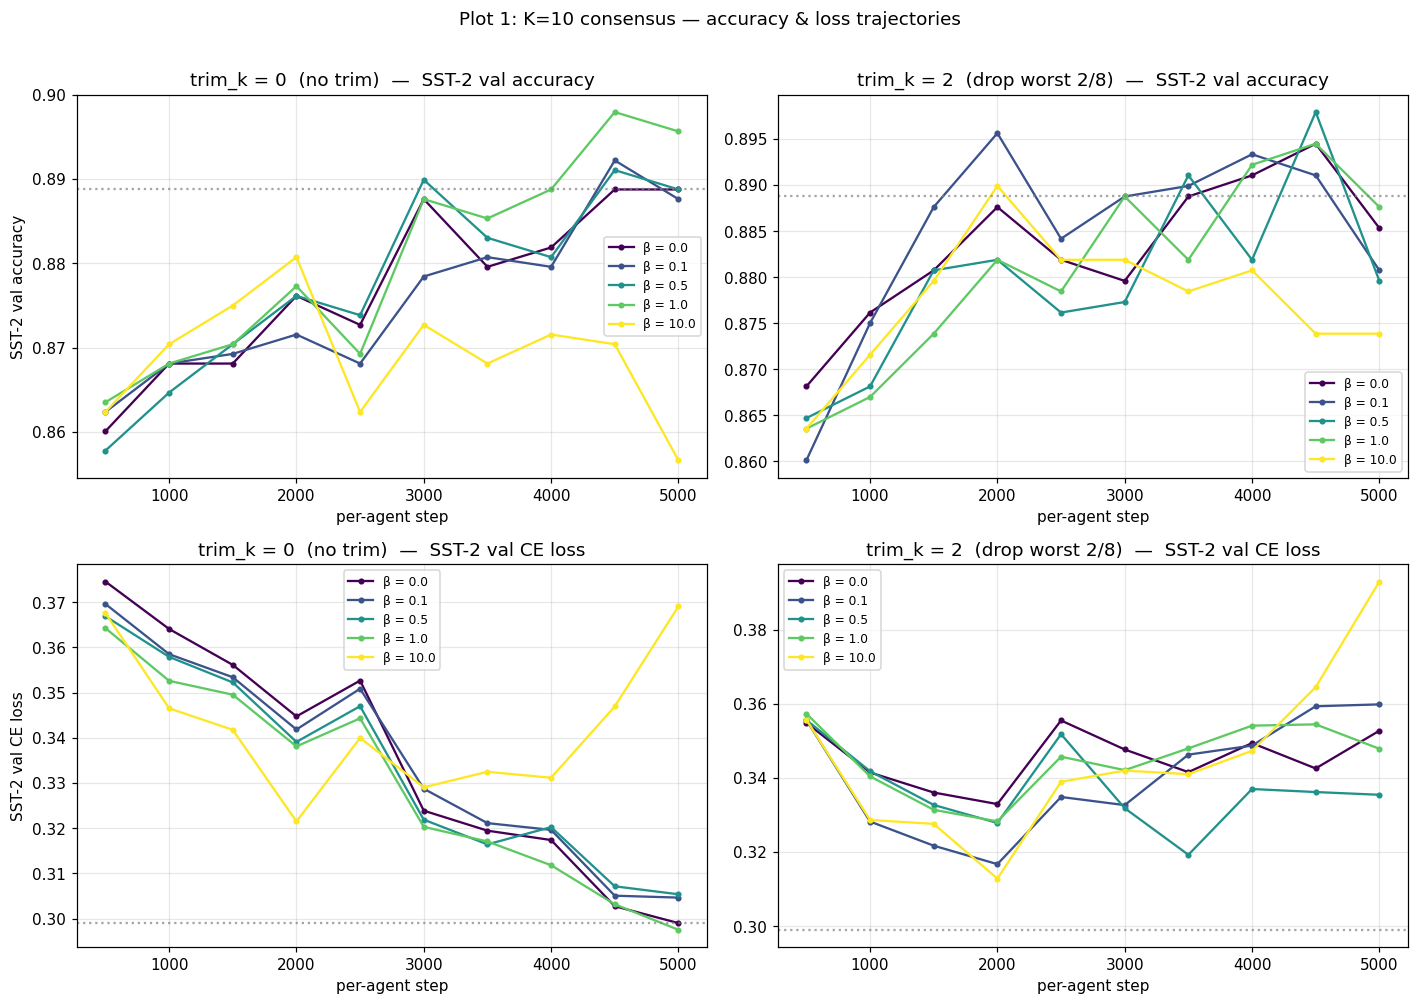

In [2]:
nt = len(trims)
fig, axes = plt.subplots(2, nt, figsize=(6.5 * nt, 9), squeeze=False)
for row, (key, ylabel, hline) in enumerate([
        ('eval_acc',  'SST-2 val accuracy', fedavg),
        ('eval_loss', 'SST-2 val CE loss',  fedavg_loss)]):
    for col, k in enumerate(trims):
        ax = axes[row][col]
        for b in betas:
            h = runs.get(f'beta{b}_trim{k}')
            if h:
                ax.plot(h['eval_step'], h[key], marker='o', markersize=3,
                        color=bcolor[b], label=f'β = {b}')
        ax.axhline(hline, color='gray', ls=':', alpha=0.7)
        ax.set_xlabel('per-agent step'); ax.grid(True, alpha=0.3)
        tag = 'no trim' if k == 0 else f'drop worst {k}/{N}'
        ax.set_title(f'trim_k = {k}  ({tag})  —  {ylabel}')
        ax.legend(fontsize=8)
        if col == 0:
            ax.set_ylabel(ylabel)
plt.suptitle('Plot 1: K=10 consensus — accuracy & loss trajectories', y=1.01)
plt.tight_layout()

## Plot 2 — final val accuracy vs β (the headline)

Two lines: `trim_k ∈ {0, 2}`. The dashed grey line is plain
FedAvg-MeZO. Read off whether `K=10` lets reputation (`β>0`) or
trimming (`trim_k=2`) beat the baseline — or whether, as at `K=100`,
β at best washes and large β cascades.

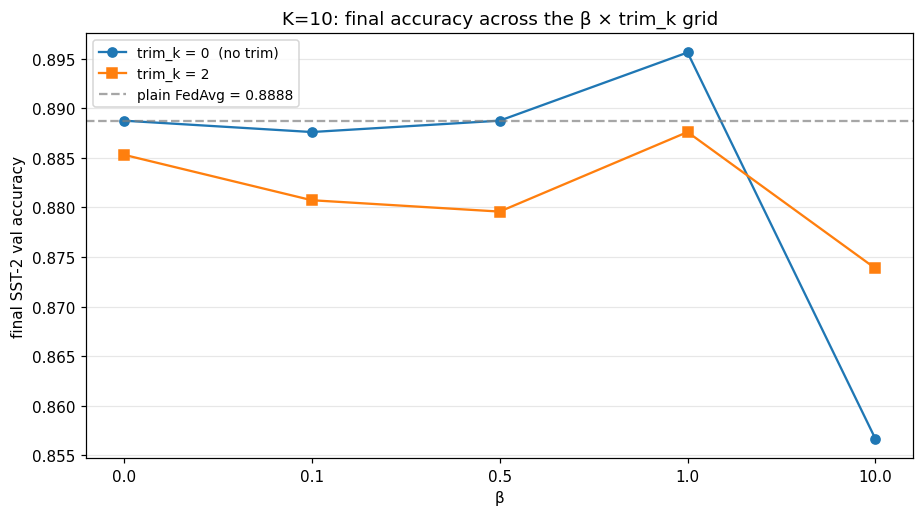

In [3]:
series = {}
for k in trims:
    series[k] = {b: runs[f'beta{b}_trim{k}']['eval_acc'][-1]
                 for b in betas if f'beta{b}_trim{k}' in runs}

x = np.arange(len(betas))
markers = {0: 'o', 2: 's', 4: '^'}
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for k, sb in series.items():
    ax.plot(x, [sb.get(b, np.nan) for b in betas], marker=markers.get(k, 'o'),
            label=f'trim_k = {k}' + ('  (no trim)' if k == 0 else ''))
ax.axhline(fedavg, color='gray', ls='--', alpha=0.7,
           label=f'plain FedAvg = {fedavg:.4f}')
ax.set_xticks(x); ax.set_xticklabels([str(b) for b in betas])
ax.set_xlabel('β'); ax.set_ylabel('final SST-2 val accuracy')
ax.set_title('K=10: final accuracy across the β × trim_k grid')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

## Plot 3 — reputation concentration over rounds (cascade detector)

`max_i r_i / Σ_j r_j` per consensus round; uniform = `1/N`. With
`K=10` there are 500 consensus rounds (vs 50 at `K=100`) — far more
chances to compound. Expect `β=10` to concentrate hard.

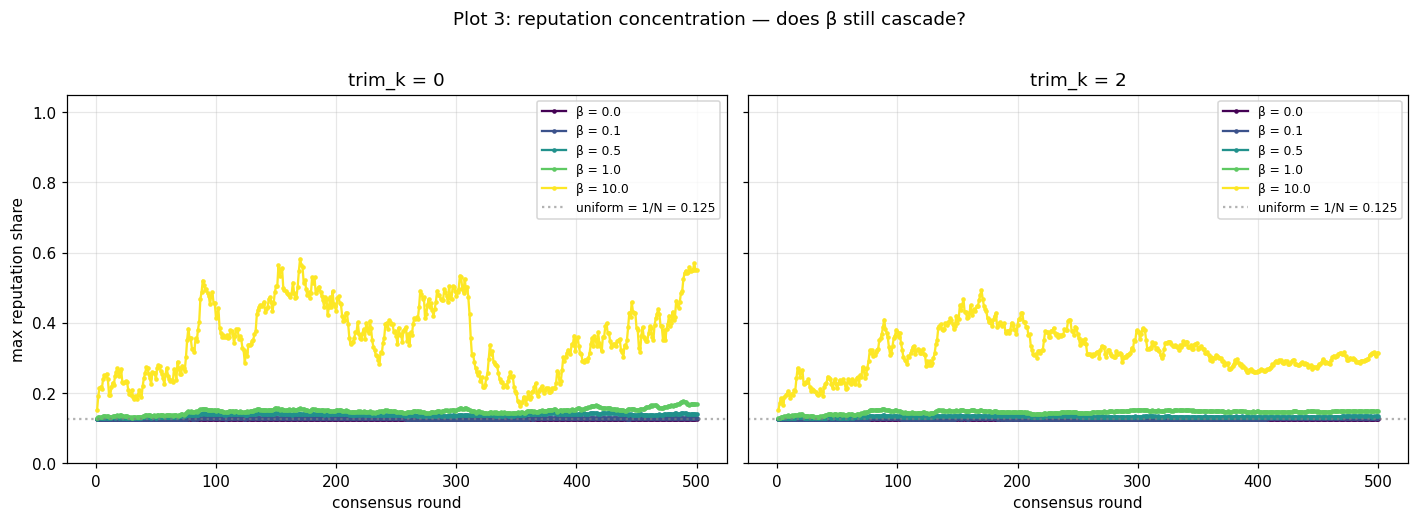

In [4]:
def _max_share(h):
    reps = np.asarray(h.get('reputations') or [])
    if reps.size == 0:
        return None
    return (reps / reps.sum(axis=1, keepdims=True)).max(axis=1)

fig, axes = plt.subplots(1, len(trims), figsize=(6.5 * len(trims), 4.6),
                         sharey=True, squeeze=False)
for ax, k in zip(axes[0], trims):
    for b in betas:
        h = runs.get(f'beta{b}_trim{k}')
        ms = _max_share(h) if h else None
        if ms is not None:
            ax.plot(np.arange(1, len(ms) + 1), ms, marker='o', markersize=2,
                    color=bcolor[b], label=f'β = {b}')
    ax.axhline(1 / N, color='gray', ls=':', alpha=0.6,
               label=f'uniform = 1/N = {1 / N:.3f}')
    ax.set_title(f'trim_k = {k}')
    ax.set_xlabel('consensus round'); ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
axes[0][0].set_ylabel('max reputation share')
plt.suptitle('Plot 3: reputation concentration — does β still cascade?', y=1.02)
plt.tight_layout()

## Plot 4 — K=10 vs K=100 head-to-head

The whole point of this run: hold everything fixed and vary only
`local_steps`. K=100 final accuracy comes from `day5_trimmed.json`
(`trim_k=2`) and `day5_reputation_iid.json` (`trim_k=0`, loss mode).
If the two K curves overlap, consensus frequency is not the lever that
opens a reputation window.

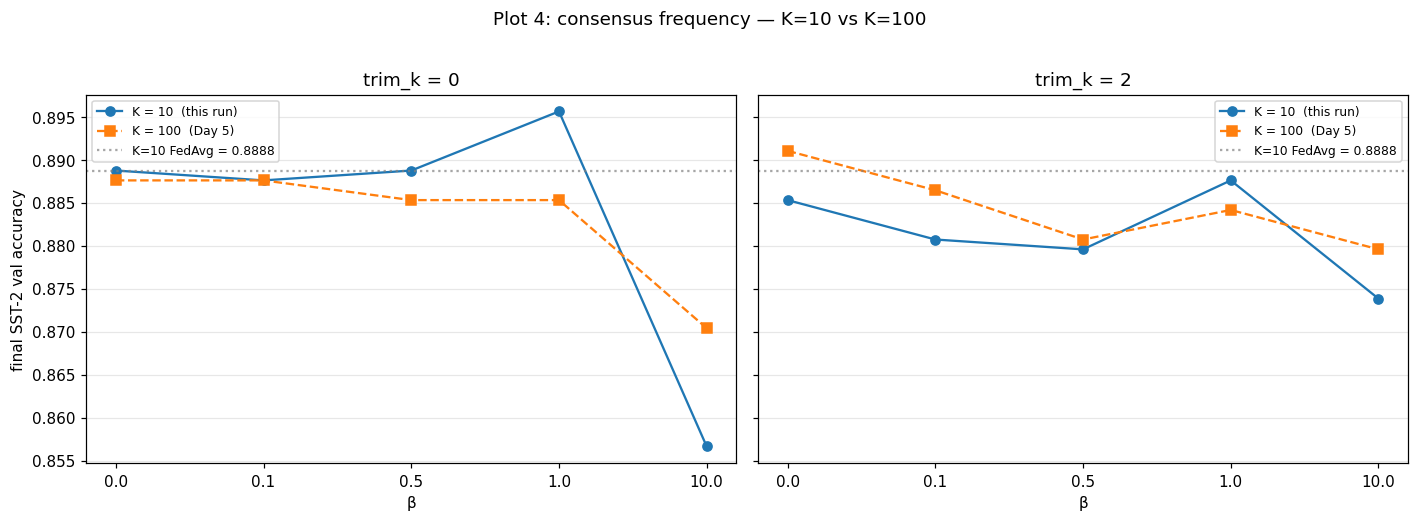

In [5]:
k100_trim = json.loads((ROOT / 'outputs' / 'day5_trimmed.json').read_text(encoding='utf-8'))['runs']
k100_rep  = json.loads((ROOT / 'outputs' / 'day5_reputation_iid.json').read_text(encoding='utf-8'))['runs']
k100_base = {h['beta']: h for h in k100_rep.values() if h.get('mode', 'loss') == 'loss'}

def k100_final(b, k):
    if k == 0:
        h = k100_base.get(b)
    else:
        h = k100_trim.get(f'beta{b}_trim{k}')
    return h['eval_acc'][-1] if h else np.nan

fig, axes = plt.subplots(1, len(trims), figsize=(6.5 * len(trims), 4.6),
                         sharey=True, squeeze=False)
for ax, k in zip(axes[0], trims):
    k10  = [series[k].get(b, np.nan) for b in betas]
    k100 = [k100_final(b, k) for b in betas]
    ax.plot(x, k10,  marker='o', label='K = 10  (this run)')
    ax.plot(x, k100, marker='s', ls='--', label='K = 100  (Day 5)')
    ax.axhline(fedavg, color='gray', ls=':', alpha=0.7,
               label=f'K=10 FedAvg = {fedavg:.4f}')
    ax.set_xticks(x); ax.set_xticklabels([str(b) for b in betas])
    ax.set_xlabel('β'); ax.set_title(f'trim_k = {k}')
    ax.grid(True, alpha=0.3, axis='y'); ax.legend(fontsize=8)
axes[0][0].set_ylabel('final SST-2 val accuracy')
plt.suptitle('Plot 4: consensus frequency — K=10 vs K=100', y=1.02)
plt.tight_layout()

## Summary table

`Δ vs FedAvg` is final accuracy minus the plain `K=10` FedAvg-MeZO
baseline (`β=0, trim_k=0`) — positive only where reputation / trimming
actually helped. `Δ vs K=100` compares against the matching `(β, trim_k)`
config at `K=100`.

In [6]:
rows = []
for k in trims:
    for b in betas:
        h = runs.get(f'beta{b}_trim{k}')
        if h is None:
            continue
        ms = _max_share(h)
        rows.append({
            'run':            f'beta{b}_trim{k}',
            'β':              b,
            'trim_k':         k,
            'final val_acc':  h['eval_acc'][-1],
            'Δ vs FedAvg':    h['eval_acc'][-1] - fedavg,
            'Δ vs K=100':     h['eval_acc'][-1] - k100_final(b, k),
            'final val_loss': h['eval_loss'][-1],
            'max rep share':  float(ms[-1]) if ms is not None else float('nan'),
        })
pd.DataFrame(rows).sort_values(['trim_k', 'β']).round(4).reset_index(drop=True)

,run,β,trim_k,final val_acc,Δ vs FedAvg,Δ vs K=100,final val_loss,max rep share
0,beta0.0_trim0,0.0,0,0.8888,0.0000,0.0011,0.2990,0.1250
1,beta0.1_trim0,0.1,0,0.8876,-0.0011,0.0000,0.3047,0.1288
2,beta0.5_trim0,0.5,0,0.8888,0.0000,0.0034,0.3054,0.1404
3,beta1.0_trim0,1.0,0,0.8956,0.0069,0.0103,0.2975,0.1688
4,beta10.0_trim0,10.0,0,0.8567,-0.0321,-0.0138,0.3691,0.5509
5,beta0.0_trim2,0.0,2,0.8853,-0.0034,-0.0057,0.3527,0.1250
6,beta0.1_trim2,0.1,2,0.8807,-0.0080,-0.0057,0.3598,0.1276
7,beta0.5_trim2,0.5,2,0.8796,-0.0092,-0.0011,0.3354,0.1331
8,beta1.0_trim2,1.0,2,0.8876,-0.0011,0.0034,0.3479,0.1485
9,beta10.0_trim2,10.0,2,0.8739,-0.0149,-0.0057,0.3930,0.3143
